In [6]:
%pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


# Exploring the sales data

This notebook takes a first look at `data/train.csv` (daily sales per store and item)
to understand its size, its date range, and the patterns a forecasting model will need to capture.

In [7]:
# Step 1: import the libraries we need
import pandas as pd              # pandas: works with tables of data (DataFrames)
import matplotlib.pyplot as plt  # matplotlib: draws charts
import seaborn as sns            # seaborn: built on matplotlib, gives nicer-looking charts

# Apply a clean, light chart style to every plot in this notebook
sns.set_theme(style="whitegrid")

# One colour for all our charts, so they look consistent
CHART_COLOR = "#2a78d6"

# Load the CSV file into a DataFrame.
# parse_dates=["date"] tells pandas to read the "date" column as real dates
# (not plain text), so we can later group by week, month, day of week, etc.
sales_df = pd.read_csv("../data/train.csv", parse_dates=["date"])

# Show the first 5 rows to check it loaded correctly
sales_df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [8]:
# Step 2: basic checks on the data

# .shape gives (number of rows, number of columns)
print("Shape (rows, columns):", sales_df.shape)

# .isna() marks every missing cell as True; .sum() counts them per column
print("\nMissing values per column:")
print(sales_df.isna().sum())

# The earliest and latest dates tell us how much history we have
print("\nFirst date:", sales_df["date"].min().date())
print("Last date: ", sales_df["date"].max().date())

Shape (rows, columns): (913000, 4)

Missing values per column:
date     0
store    0
item     0
sales    0
dtype: int64

First date: 2013-01-01
Last date:  2017-12-31


In [9]:
# Step 3: how many different stores and items are there?
# .nunique() counts the number of distinct values in a column
num_stores = sales_df["store"].nunique()
num_items = sales_df["item"].nunique()

print("Unique stores:", num_stores)
print("Unique items: ", num_items)
print("Store-item combinations:", num_stores * num_items)

Unique stores: 10
Unique items:  50
Store-item combinations: 500


## Overall trend: weekly total sales

This line chart adds up the sales of **every store and every item** for each week and plots
those totals over the whole date range. We use weekly totals instead of daily ones because
daily numbers jump around a lot, which hides the bigger picture.

**Why it matters for forecasting:** it shows whether sales are growing, shrinking, or flat
over the years (the *trend*), and whether the same ups and downs repeat every year
(*yearly seasonality*). A good forecast has to continue both patterns into the future.

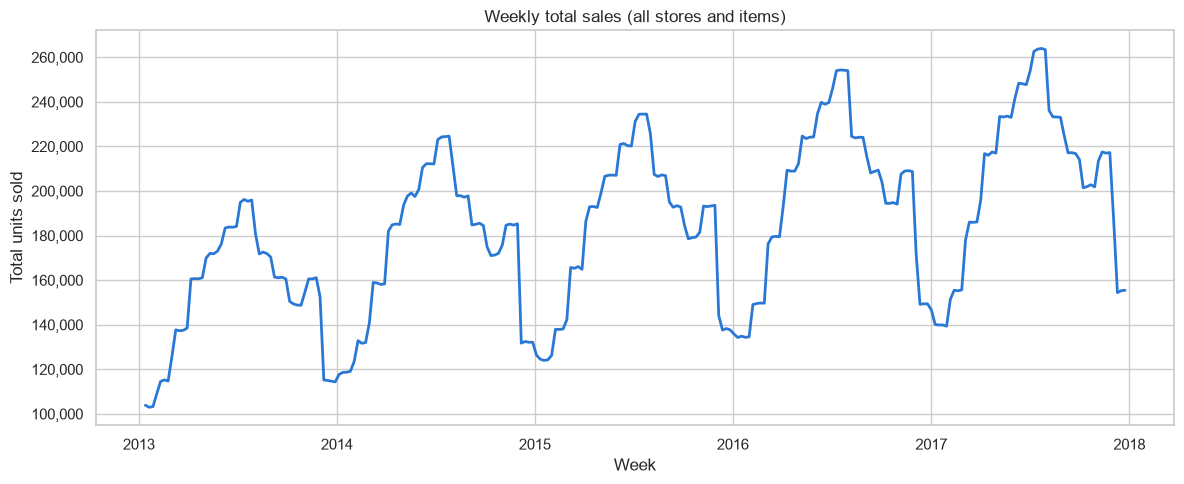

In [10]:
# Step 4: weekly total sales over time

# .resample("W", on="date") groups the rows into calendar weeks using the "date" column,
# then .sum() adds up the sales in each week
weekly_sales = sales_df.resample("W", on="date")["sales"].sum()

# The first and last weeks may be only partly covered by the data,
# which makes their totals look artificially low, so we drop them
weekly_sales = weekly_sales.iloc[1:-1]

# Create the figure (width 12 inches, height 5 inches) and draw the line
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(weekly_sales.index, weekly_sales.values, color=CHART_COLOR, linewidth=2)

# Titles and axis labels so the chart explains itself
ax.set_title("Weekly total sales (all stores and items)")
ax.set_xlabel("Week")
ax.set_ylabel("Total units sold")

# Show y-axis numbers with thousands separators, e.g. 150,000
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))

plt.tight_layout()
plt.show()

## Average sales by day of week

This bar chart shows the **average number of units sold per store-item on each weekday**,
from Monday to Sunday.

**Why it matters for forecasting:** if some days are consistently busier than others
(for example weekends), the model needs to know which day it is predicting for.
This tells us "day of week" is a useful input feature.

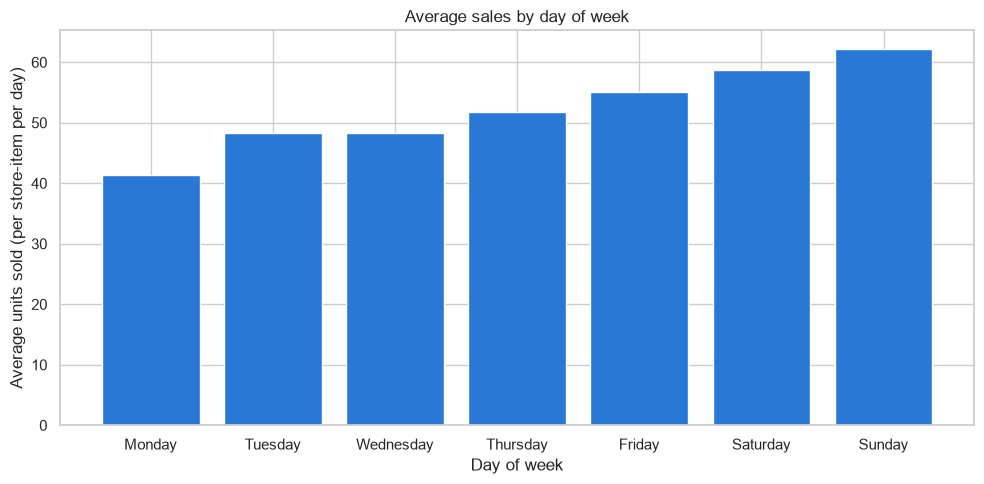

In [11]:
# Step 5: average sales by day of week

# .dt.day_name() turns each date into its weekday name, e.g. "Monday"
sales_df["day_of_week"] = sales_df["date"].dt.day_name()

# Group all rows by weekday and take the average (mean) of sales
avg_sales_by_day = sales_df.groupby("day_of_week")["sales"].mean()

# groupby sorts the names alphabetically (Friday, Monday, ...),
# so we put them back into calendar order with .reindex()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
avg_sales_by_day = avg_sales_by_day.reindex(day_order)

# Draw the bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_sales_by_day.index, avg_sales_by_day.values, color=CHART_COLOR)

ax.set_title("Average sales by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Average units sold (per store-item per day)")

plt.tight_layout()
plt.show()

## Average sales by month

This bar chart shows the **average number of units sold per store-item per day in each month**,
from January to December, combining all years together.

**Why it matters for forecasting:** it reveals the yearly seasonal pattern, i.e. which months
are busy and which are quiet. The model should know the month (or time of year) so it can
predict higher demand in peak months and avoid overstocking in slow ones.

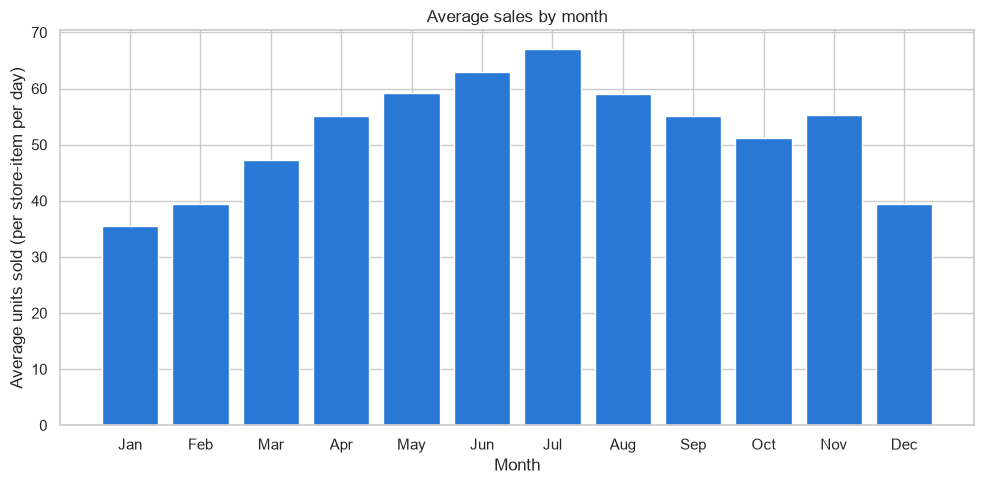

In [12]:
# Step 6: average sales by month

# .dt.month gives the month number (1 = January ... 12 = December).
# Grouping by the number keeps the months in calendar order automatically.
sales_df["month"] = sales_df["date"].dt.month
avg_sales_by_month = sales_df.groupby("month")["sales"].mean()

# Short month names to use as bar labels, in calendar order
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Draw the bar chart
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(month_names, avg_sales_by_month.values, color=CHART_COLOR)

ax.set_title("Average sales by month")
ax.set_xlabel("Month")
ax.set_ylabel("Average units sold (per store-item per day)")

plt.tight_layout()
plt.show()

## Data Cleaning Checks

Before building a forecast we make sure the data has no obvious problems.
Each check below prints its result, and any problem it finds is added to a list
that the last cell sums up.

In [13]:
# The four original columns from the CSV. The charts above added helper columns
# (day_of_week, month), so we name the originals here to check only the raw data.
original_columns = ["date", "store", "item", "sales"]

# Every check adds a message to this list when it finds a problem.
# If the list is still empty at the end, the data is clean.
cleaning_issues = []

# Check 1: fully duplicate rows (every column identical).
# Why it matters: an exact copy of a row counts the same sale twice,
# which inflates demand and makes the forecast too high.
# .duplicated() marks a row True if an identical row appeared earlier.
num_full_duplicates = sales_df.duplicated(subset=original_columns).sum()

print("CHECK 1 - Fully duplicate rows")
print("  Count:", num_full_duplicates)

if num_full_duplicates > 0:
    cleaning_issues.append(f"{num_full_duplicates} fully duplicate rows (remove the extra copies)")

CHECK 1 - Fully duplicate rows
  Count: 0


In [14]:
# Check 2: duplicate keys with conflicting sales.
# Each (date, store, item) combination should appear only once, with one sales number.
# If the same combination appears twice with DIFFERENT sales, we don't know which
# number is correct, so the data is ambiguous.
key_columns = ["date", "store", "item"]

# For each key, count how many different sales values it has.
# .transform("nunique") writes that count back onto every row, so we can filter rows with it.
sales_values_per_key = sales_df.groupby(key_columns)["sales"].transform("nunique")
conflicting_rows = sales_df[sales_values_per_key > 1]

print("CHECK 2 - Duplicate keys (same date/store/item, different sales)")
print("  Rows involved:", len(conflicting_rows))

if len(conflicting_rows) > 0:
    # Sort so the rows sharing a key are shown next to each other
    print(conflicting_rows[original_columns].sort_values(key_columns).to_string())
    cleaning_issues.append(
        f"{len(conflicting_rows)} rows have the same date/store/item but different sales (decide which value to keep)"
    )

CHECK 2 - Duplicate keys (same date/store/item, different sales)
  Rows involved: 0


In [15]:
# Check 3: column data types.
# Why it matters: if 'date' were stored as text, pandas couldn't sort it by time,
# group it by week or month, or pull out the weekday. It must be a datetime type.
print("CHECK 3 - Column data types")
print(sales_df[original_columns].dtypes.to_string())

# is_datetime64_any_dtype returns True if the column holds real dates
date_is_datetime = pd.api.types.is_datetime64_any_dtype(sales_df["date"])
print("  'date' is a datetime type:", date_is_datetime)

if not date_is_datetime:
    cleaning_issues.append("'date' column is not a datetime (convert it with pd.to_datetime)")

CHECK 3 - Column data types
date     datetime64[us]
store             int64
item              int64
sales             int64
  'date' is a datetime type: True


In [16]:
# Check 4: negative sales.
# Why it matters: you can't sell fewer than zero units. Negative numbers usually
# mean returns or data-entry errors, and they would drag the forecast down.
negative_sales_rows = sales_df[sales_df["sales"] < 0]

print("CHECK 4 - Negative sales values")
print("  Count:", len(negative_sales_rows))

if len(negative_sales_rows) > 0:
    print(negative_sales_rows[original_columns].to_string())
    cleaning_issues.append(f"{len(negative_sales_rows)} rows have negative sales (investigate or remove)")

CHECK 4 - Negative sales values
  Count: 0


In [17]:
# Final summary: one line if everything passed, otherwise a list of what to fix
print("SUMMARY")
if len(cleaning_issues) == 0:
    print("Data is clean")
else:
    print("Needs fixing:")
    for issue in cleaning_issues:
        print("  -", issue)

SUMMARY
Data is clean
